In [1]:
import numpy as np
import pandas as pd
from astroquery.gaia import Gaia
from astroquery.simbad import Simbad
import matplotlib.pyplot as plt
from astropy.table import Column, join, Table, vstack, hstack, MaskedColumn
from astropy.io import ascii
from HMXB_pipeline_class import pipeline
import astropy.coordinates as coords
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.visualization import astropy_mpl_style
from astropy.stats import sigma_clip
from datetime import datetime
import os

Due to scheduled ESAC network maintenance activities, all archives will be temporarily unavailable on Thursday, 17 July 2025, from 9:00 to 12:00 CEST. We apologize for the inconvenience


In [2]:
cwd = os.getcwd()
cwd
home_files = os.path.dirname(cwd)
home_files = home_files + '/'
csv_files  = home_files + 'DATA/'
csv_files

'/home/karan/Documents/UvA/Thesis/DATA/'

In [3]:
from astropy.table import Table
from astropy.io.votable import parse

# Load the full table
gosc = parse(csv_files + 'Gosc.xml')


# Extract the first resource and first table
first_table = gosc.get_first_table()

# Convert to an Astropy Table
gosc_table = first_table.to_table()



# Column 6 7, Ra deg, dec deg, col 12: association

In [4]:
gosc_table

col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,col11,col12
str1,str1,str1,str1,str1,float64,float64,float64,float64,str1,str1,str1
1,M,1,0,+,68.0076875,53.9108417,151.9142569,3.9508249,T,,C
1,M,0,2,+,339.8153292,39.0502806,96.6508907,-16.9833387,T,S,L
1,M,1,2,+,330.5190667,58.0003694,102.0051587,2.1834475,T,,C
1,M,2,0,+,100.2444,9.8957528,202.9363074,2.1984746,T,N,M
1,M,0,1,-,273.8037708,-20.7282667,10.455741,-1.7407522,T,R,S
1,M,0,1,-,273.8040417,-20.3879694,10.7551989,-1.5788802,T,R,S
1,M,1,2,+,331.2866292,62.2798194,104.8706302,5.390644,T,A,C
2,M,2,0,-,109.6682417,-24.5587,237.8243862,-5.3678858,T,N,C
2,M,2,1,-,155.6706708,-59.5084944,285.0612243,-1.9005879,M,,C


In [5]:
gosc_df = gosc_table.to_pandas()

In [6]:
pd.unique(gosc_df['col12'])

array(['C', 'L', 'M', 'S', '', 'O', 'A', 'P', 'V', 'N', 'm', 'G', 'U'],
      dtype=object)

In [7]:
#only interersted in stars with confirmed OB associations
gosc_df = gosc_df[~gosc_df['col12'].isin(['m', ''])]

In [8]:
gosc_df

,col1,col2,col3,col4,col5,col6,col7,col8,col9,col10,col11,col12
0,1,M,1,0,+,68.007688,53.910842,151.914257,3.950825,T,,C
1,1,M,0,2,+,339.815329,39.050281,96.650891,-16.983339,T,S,L
2,1,M,1,2,+,330.519067,58.000369,102.005159,2.183448,T,,C
3,1,M,2,0,+,100.244400,9.895753,202.936307,2.198475,T,N,M
4,1,M,0,1,-,273.803771,-20.728267,10.455741,-1.740752,T,R,S
...,...,...,...,...,...,...,...,...,...,...,...,...
606,x,M,1,0,+,59.741250,35.791033,160.372282,-13.106536,T,N,P
607,z,M,0,1,-,249.289708,-10.567153,6.281152,23.587732,T,S,U
608,z,M,2,0,-,85.189696,-1.942572,206.452178,-16.585165,T,C,O
609,z,M,2,0,-,85.189879,-1.943219,206.452865,-16.585304,T,C,O


In [9]:
from astropy.coordinates import SkyCoord
import astropy.units as u

filtered_df = gosc_df.rename(columns={'col6': 'RA_deg', 'col7': 'Dec_deg'})

In [10]:
filtered_df

,col1,col2,col3,col4,col5,RA_deg,Dec_deg,col8,col9,col10,col11,col12
0,1,M,1,0,+,68.007688,53.910842,151.914257,3.950825,T,,C
1,1,M,0,2,+,339.815329,39.050281,96.650891,-16.983339,T,S,L
2,1,M,1,2,+,330.519067,58.000369,102.005159,2.183448,T,,C
3,1,M,2,0,+,100.244400,9.895753,202.936307,2.198475,T,N,M
4,1,M,0,1,-,273.803771,-20.728267,10.455741,-1.740752,T,R,S
...,...,...,...,...,...,...,...,...,...,...,...,...
606,x,M,1,0,+,59.741250,35.791033,160.372282,-13.106536,T,N,P
607,z,M,0,1,-,249.289708,-10.567153,6.281152,23.587732,T,S,U
608,z,M,2,0,-,85.189696,-1.942572,206.452178,-16.585165,T,C,O
609,z,M,2,0,-,85.189879,-1.943219,206.452865,-16.585304,T,C,O


In [11]:
filtered_df['RA_deg'] = pd.to_numeric(filtered_df['RA_deg'], errors='coerce')
filtered_df['Dec_deg'] = pd.to_numeric(filtered_df['Dec_deg'], errors='coerce')
filtered_df = filtered_df.dropna(subset=['RA_deg', 'Dec_deg'])

# Step 4: Now create SkyCoord safely
gosc_coords = SkyCoord(ra=filtered_df['RA_deg'].values * u.deg,
                  dec=filtered_df['Dec_deg'].values * u.deg,
                  frame='icrs')

In [12]:
Gaia_coords = pd.DataFrame({
    'ra': filtered_df['RA_deg'],
    'dec': filtered_df['Dec_deg']
})

Gaia_coords.to_csv(csv_files+"Gosc_gaia_target.csv", index=False,float_format='%.8f')

In [13]:
type(Gaia_coords['dec'][0])

numpy.float64

# Gaia Query

In [14]:
# from astroquery.gaia import Gaia
# from astropy.table import Table
# import numpy as np

# # Upload GOSC coordinates as a temporary Gaia table
# gosc_coords_table = Table()
# gosc_coords_table['ra'] = Gaia_coords.ra.deg
# gosc_coords_table['dec'] = Gaia_coords.dec.deg

# # Upload to Gaia archive
# job = Gaia.launch_job_async("""
#     SELECT TOP 1000 * FROM gaiaedr3.gaia_source
# """)
# gaia_columns = job.get_results().colnames

In [15]:

# Step 1: Rename RA/Dec columns if not already done
ra_col = gosc_df.columns[5]
dec_col = gosc_df.columns[6]
gosc_df = gosc_df.rename(columns={ra_col: 'RA_deg', dec_col: 'Dec_deg'})

# Step 2: Filter col12 ('u' or blank) again
col12 = gosc_df.columns[11]
filtered_df = gosc_df[~gosc_df[col12].isin(['u', ' '])]

# Step 3: Convert RA/Dec to numeric and drop invalids
filtered_df['RA_deg'] = pd.to_numeric(filtered_df['RA_deg'], errors='coerce')
filtered_df['Dec_deg'] = pd.to_numeric(filtered_df['Dec_deg'], errors='coerce')
filtered_df = filtered_df.dropna(subset=['RA_deg', 'Dec_deg'])

# Step 4: Now create SkyCoord safely
gosc_coords = SkyCoord(ra=filtered_df['RA_deg'].values * u.deg,
                  dec=filtered_df['Dec_deg'].values * u.deg,
                  frame='icrs')



In [16]:
# upload_table = Table()
# upload_table['ra'] = gosc_coords.ra.deg
# upload_table['dec'] = gosc_coords.dec.deg

# # Upload to Gaia archive (use unique table name)
# upload_table_name = "skycoord_targets"
# Gaia.upload_table(upload_resource=upload_table,
#                   table_name=upload_table_name,
#                   format='astropy')


In [17]:
filtered_df['RA_deg']

0       68.007688
1      339.815329
2      330.519067
3      100.244400
4      273.803771
          ...    
606     59.741250
607    249.289708
608     85.189696
609     85.189879
610    120.896029
Name: RA_deg, Length: 440, dtype: float64

In [18]:
gosc_gaia = ascii.read(csv_files+'gosc_gaia2-result.ecsv',format='ecsv')
gosc_gaia

ra,dec,source_id,ra_1,ra_error,dec_1,dec_error,pmra,pmra_error,pmdec,pmdec_error,ruwe,radial_velocity,radial_velocity_error,parallax,parallax_error,l,b,separation_arcsec
deg,deg,,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,,km / s,km / s,mas,mas,deg,deg,
float64,float64,int64,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float64,float32,float64,float64,float64
68.0076875,53.9108417,273895291446188288,68.00769054760464,0.03666353,53.91082090210578,0.026822818,2.774582151562507,0.05089641,-3.7826001756140473,0.040601917,1.2225959,--,--,1.26300967421916,0.04858999,151.91427332039,3.9508120313064485,0.0751508123774058
339.8153292,39.0502806,1908095850396090880,339.81531786163464,0.072042614,39.050245202400795,0.08609725,-1.2742682584235756,0.117753804,-5.605162748426952,0.11995562,1.207359,--,--,2.1920082768196245,0.13135453,96.65086399268186,-16.983364738781276,0.13131482353220156
330.5190667,58.0003694,2199161386015469312,330.51902664934903,0.04211673,58.00035221519391,0.048406515,-3.0956156814310263,0.0608079,-2.611488332618345,0.05402527,0.72731763,--,--,0.9070475104162397,0.052451357,102.00513137868745,2.183446439436868,0.09831033595137574
100.2444,9.8957528,3326740865570982400,100.24441664679023,1.035055,9.895739133621289,1.1320215,0.9026908977929937,1.1391255,-6.445872123354507,1.0634965,5.060141,--,--,-1.3292349046808456,1.0003312,202.93632708619563,2.1984829825830965,0.0768497615560132
273.8037708,-20.7282667,4093968702062993664,273.8037832649009,0.10505804,-20.72827600390888,0.11639099,1.450646789115871,0.13608544,-1.6258556506383528,0.09616716,1.0795453,--,--,0.8769077486837962,0.16677898,10.455738373852386,-1.7407668904460305,0.05369586228246584
273.8040417,-20.3879694,4094031138050641408,273.80404921555873,0.27672285,-20.387978918638318,0.2177444,2.4463651357209018,0.282547,-2.066297047486776,0.21202433,4.901783,--,--,0.06414678648829153,0.3241028,10.755193932589895,-1.578890912209009,0.042631196805752926
331.2866292,62.2798194,2205660290000075392,331.2866087282461,0.052877635,62.27980115248062,0.06149198,-1.5954178382982744,0.073070765,-3.0263123960888,0.07208635,0.7683234,--,--,1.0221496763735376,0.0651784,104.87061157640595,5.390634939449479,0.07409796318686018
109.6682417,-24.5587,5617678822143017088,109.66823156630946,0.05944102,-24.55868316646098,0.096721105,-2.8645731356236808,0.07198771,3.6780785373619795,0.1287465,1.8710642,--,--,0.8549491665900713,0.1276947,237.8243669470896,-5.367886153749638,0.06909002350461657


In [19]:
#string map
str_map = ','.join(map(str,gosc_gaia['source_id']))
#str_map

# Query Bailer Jones

In [20]:
bailer_jones = ascii.read(csv_files+'gosc_bailer_jones.csv',format='csv')
bailer_jones['r_med_photogeo'] = bailer_jones['r_med_photogeo']/1000
bailer_jones['r_med_photogeo'].unit = u.kpc

bailer_jones['r_hi_photogeo'] = bailer_jones['r_hi_photogeo']/1000
bailer_jones['r_hi_photogeo'].unit = u.kpc

bailer_jones['r_lo_photogeo'] = bailer_jones['r_lo_photogeo']/1000
bailer_jones['r_lo_photogeo'].unit = u.kpc

In [21]:
bailer_jones.rename_columns(['r_med_photogeo', 'r_lo_photogeo', 'r_hi_photogeo'], ['distance_bj','distance_bj_low','distance_bj_high'])


In [22]:
gosc_gaia = join(gosc_gaia,bailer_jones,keys='source_id',join_type='left')
gosc_gaia.rename_columns(['radial_velocity','radial_velocity_error'],['RV','RV_err'])
gosc_gaia.write(csv_files+'gosc_gaia_for_pipeline.ecsv',format='ascii.ecsv',overwrite=True)

In [23]:
gosc_gaia

ra,dec,source_id,ra_1,ra_error,dec_1,dec_error,pmra,pmra_error,pmdec,pmdec_error,ruwe,RV,RV_err,parallax,parallax_error,l,b,separation_arcsec,distance_bj,distance_bj_low,distance_bj_high
deg,deg,,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,,km / s,km / s,mas,mas,deg,deg,,kpc,kpc,kpc
float64,float64,int64,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float64,float32,float64,float64,float64,float64,float64,float64
58.8461583,31.0458444,168450545792009600,58.84615062234396,0.029553613,31.045836091857545,0.020791648,-1.282117252826291,0.053073816,-1.8690907560201113,0.030308086,1.5027114,--,--,1.627402622661778,0.03745641,163.0813533466715,-17.136203125538678,0.03814872348808245,0.6001466000000001,0.586646,0.6135245
80.6670792,33.3192722,181167218106890368,80.66706435274119,0.4163247,33.31927297546451,0.31453758,-0.10327186642021877,0.52390236,-1.0723971651947048,0.37266865,20.990484,--,--,-0.21586713890459042,0.46388048,173.65350390083844,-1.7439613318705967,0.04475129995545133,5.2745005,3.4032175000000002,6.9794136
80.665375,33.3717306,181173402856344704,80.66534570892918,0.018223742,33.371731571667866,0.012962326,-0.42668288424132433,0.024813656,-1.5284710648083066,0.015249231,0.9692947,62.587734,27.006443,0.3029834178805304,0.019905336,173.60942287108568,-1.7154552128138987,0.08813099217819828,3.0023018,2.8448670000000003,3.1648345
80.693925,33.4198639,181174025630477056,80.69393319295438,0.028311808,33.41986213174406,0.019488927,-0.15962315069243596,0.03462848,-1.3062573806849227,0.023332613,1.1119173,--,--,0.4528118928547797,0.033759102,173.5832341327936,-1.66854093673724,0.025427614529034682,2.1438247,1.997335,2.351623
80.6833417,33.4407361,181174781544714880,80.68332521274716,0.02218698,33.44073201989605,0.015251279,-0.5010727050522239,0.029204788,-1.3256564058550846,0.018375698,1.1392024,--,--,0.3681592222867326,0.025466228,173.56100769153815,-1.6640320393158374,0.05166054397110086,2.4822412,2.3391228,2.641395
80.6220917,33.5140083,181178389317231616,80.62208870730313,0.018956836,33.514011992939686,0.013097594,-0.9044919402230558,0.023448449,-0.6843667868323584,0.016163599,0.9799654,--,--,0.29280649562311944,0.020289902,173.47164759171167,-1.6646510408460842,0.016044713531922616,3.0132312000000003,2.8327979,3.2568699000000003
79.0756208,34.3123139,182071570715713024,79.07559666990984,0.03253635,34.31251139077335,0.021343945,-4.74655801090574,0.04624765,43.53767238272993,0.03277261,0.9930748,--,--,2.573988882528692,0.033972435,172.08114110834472,-2.259140767320703,0.7145781959641895,0.38020044000000003,0.3752654,0.38476196
81.9006125,34.7552667,182855316348701824,81.90060459226433,0.036515456,34.75526961182701,0.026954662,-0.5958464803907317,0.039705917,-2.0189840662391623,0.03246127,1.447818,--,--,0.27156109410724605,0.04249433,173.03830953182003,-0.09214387756582765,0.025630666675386063,3.279259,2.8906419999999997,3.816275


In [24]:
print(np.mean(gosc_gaia['separation_arcsec']))
np.std(gosc_gaia['separation_arcsec'])

0.11243476536502109


np.float64(0.12340062645448424)

In [25]:
HMXB_pipeline = pipeline(csv_files+'gosc_gaia_for_pipeline.ecsv', fmt='ecsv')
#HMXB_table = HMXB_pipeline.complie_table(filename=csv_files+'HMXB_with_analysis.ecsv',filetype='ascii.ecsv')
gosc_table = HMXB_pipeline.complie_table(filename=csv_files+'gosc_gaia_vpec.ecsv',filetype='ascii.ecsv')

/home/karan/Documents/UvA/Thesis/Code/HMXB_pipeline_class.py:121: RuntimeWarning: divide by zero encountered in divide
  V_lsr = (theta * (self.R0/gal_dist) - self.sun_curve)*np.sin(long_rad)*np.cos(lat_rad)
/home/karan/Documents/UvA/Thesis/Code/HMXB_pipeline_class.py:270: RuntimeWarning: divide by zero encountered in divide
  omega = theta/R
/home/karan/Documents/UvA/Thesis/Code/HMXB_pipeline_class.py:284: RuntimeWarning: invalid value encountered in multiply
  RV_rot = R*(omega-omega_0)*np.cos(lat_rad)*np.sin(long_rad)
/home/karan/Documents/UvA/Thesis/Code/HMXB_pipeline_class.py:325: RuntimeWarning: invalid value encountered in sqrt
  V_pec = self.k*dist*np.sqrt(pec_mu_l**2 + pec_mu_b**2)


In [26]:
gosc_table
gosc_pd = gosc_table.to_pandas()

In [27]:
gosc_pd

,ra,dec,source_id,ra_1,ra_error,dec_1,dec_error,pmra,pmra_error,pmdec,...,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err
0,58.846158,31.045844,168450545792009600,58.846151,0.029554,31.045836,0.020792,-1.282117,0.053074,-1.869091,...,8.331080,-1.921687,-0.334062,-3.290182,9.786737,NaN,-3.440302,-0.017502,NaN,0.014443
1,80.667079,33.319272,181167218106890368,80.667064,0.416325,33.319273,0.314538,-0.103272,0.523902,-1.072397,...,9.457474,-0.363794,-0.011774,-15.899208,17.902465,NaN,0.605187,-0.382752,NaN,8.692245
2,80.665375,33.371731,181173402856344704,80.665346,0.018224,33.371732,0.012962,-0.426683,0.024814,-1.528471,...,9.442517,-0.498818,-0.013719,-8.908174,11.961794,62.053391,0.490457,-0.682625,63.19579,0.243382
3,80.693925,33.419864,181174025630477056,80.693933,0.028312,33.419862,0.019489,-0.159623,0.034628,-1.306257,...,9.429795,-0.611020,-0.014231,-6.263326,2.045370,NaN,0.154228,-0.129336,NaN,0.177743
4,80.683342,33.440736,181174781544714880,80.683325,0.022187,33.440732,0.015251,-0.501073,0.029205,-1.325656,...,9.423509,-0.558958,-0.013917,-7.344361,6.307131,NaN,0.123814,-0.521561,NaN,0.206517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440,254.062608,-40.659933,5969673420936964864,254.062626,0.567029,-40.659950,0.374356,2.651716,0.781615,4.601572,...,-7.016467,-1.879104,0.093636,-34.608024,190.453234,NaN,7.792514,0.984093,NaN,1.999805
441,253.730713,-40.524828,5969686958696979712,253.730701,0.026448,-40.524837,0.016787,-0.823504,0.036074,-1.242868,...,-7.037994,-0.430118,0.065706,-12.669690,9.596030,NaN,0.963340,0.735145,NaN,0.094796
442,254.227817,-40.512331,5969698194333785088,254.227791,0.185599,-40.512346,0.120292,0.260358,0.264115,-0.104365,...,-7.069679,-0.641901,0.059106,-16.985477,24.230737,NaN,2.162056,0.340624,NaN,0.482963
443,254.021733,-40.349333,5969715271123841280,254.021727,0.022515,-40.349333,0.015894,-0.813720,0.032142,-1.436136,...,-7.106762,-0.408161,0.062530,-12.442690,7.964123,NaN,0.795856,0.618628,NaN,0.091197


In [28]:
gosc_table

ra,dec,source_id,ra_1,ra_error,dec_1,dec_error,pmra,pmra_error,pmdec,pmdec_error,ruwe,RV,RV_err,parallax,parallax_error,l,b,separation_arcsec,distance_bj,distance_bj_low,distance_bj_high,distance_para,pm_l_poleski,pm_b_poleski,galactic distance,circular velocity,LSR velocity,mu_l_sol,mu_b_sol,RV_r_sol,mu_l_rot,mu_b_rot,RV_rot,Peculiar Velocity,Peculiar Radial Velocity,peculiar_mu_l,peculiar_mu_b,Peculiar Velocity 3D,dist_err
deg,deg,,deg,mas,deg,mas,mas / yr,mas / yr,mas / yr,mas / yr,,km / s,km / s,mas,mas,deg,deg,,kpc,kpc,kpc,kpc,mas / yr,mas / yr,kpc,km / s,km / s,mas / yr,mas / yr,km / s,mas / yr,mas / yr,km / s,km / s,km / s,mas / yr,mas / yr,km / s,kpc
float64,float64,int64,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32,float32,float64,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
58.8461583,31.0458444,168450545792009600,58.84615062234396,0.029553613,31.045836091857545,0.020791648,-1.282117252826291,0.053073816,-1.8690907560201113,0.030308086,1.5027114,--,--,1.610402622661778,0.03745641,163.0813533466715,-17.136203125538678,0.03814872348808245,0.6001466000000001,0.586646,0.6135245,0.6209627244316922,0.31676504048036086,-2.2443227961601564,8.700283372674695,240.10342425051675,-3.082081921386132,5.678754520826265,-1.8927588919495255,8.331080353841104,-1.9216873115359343,-0.33406197379682595,-3.2901823428045422,9.786736621156699,--,-3.4403021688099704,-0.017501930413804934,--,0.014442992653281752
80.6670792,33.3192722,181167218106890368,80.66706435274119,0.4163247,33.31927297546451,0.31453758,-0.10327186642021877,0.52390236,-1.0723971651947048,0.37266865,20.990484,--,--,0.23101334043119448,0.46388048,173.65350390083844,-1.7439613318705967,0.04475129995545133,5.2745005,3.4032175000000002,6.9794136,4.328754340045752,0.8297863794702405,-0.6871355927014875,13.402424443738497,244.1970741296458,-9.668291330106435,0.5883931490616892,-0.2926094528952938,9.457473576208312,-0.36379423157952995,-0.011774389981363586,-15.89920785911699,17.902465212232617,--,0.6051874619880813,-0.3827517498248301,--,8.692245367472003
80.665375,33.3717306,181173402856344704,80.66534570892918,0.018223742,33.371731571667866,0.012962326,-0.42668288424132433,0.024813656,-1.5284710648083066,0.015249231,0.9692947,62.587734,27.006443,0.2859834178805304,0.019905336,173.60942287108568,-1.7154552128138987,0.08813099217819828,3.0023018,2.8448670000000003,3.1648345,3.4967062335682346,1.025837475345567,-1.2107599075941389,11.137319026013419,242.4345244772147,-6.5187698531601255,1.0341989118681154,-0.5144162043282774,9.442517412957365,-0.49881830716772246,-0.01371890691976024,-8.908174173227357,11.961793981332216,62.053390982682096,0.49045687064517407,-0.6826247963461013,63.195789794110866,0.24338163971819007
80.693925,33.4198639,181174025630477056,80.69393319295438,0.028311808,33.41986213174406,0.019488927,-0.15962315069243596,0.03462848,-1.3062573806849227,0.023332613,1.1119173,--,--,0.43581189285477967,0.033759102,173.5832341327936,-1.66854093673724,0.025427614529034682,2.1438247,1.997335,2.351623,2.2945679463897006,0.9919588728609186,-0.8647574743147995,10.282280362546016,241.67800152301785,-4.964473593417869,1.448749953558416,-0.7211898671318486,9.429794846303205,-0.611019507542634,-0.014231236007894547,-6.263326299383907,2.0453696443691296,--,0.1542284268451365,-0.12933637117505636,--,0.17774309314428663
80.6833417,33.4407361,181174781544714880,80.68332521274716,0.02218698,33.44073201989605,0.015251279,-0.5010727050522239,0.029204788,-1.3256564058550846,0.018375698,1.1392024,--,--,0.3511592222867326,0.025466228,173.56100769153815,-1.6640320393158374,0.05166054397110086,2.4822412,2.3391228,2.641395,2.847711056790838,0.8163935157994995,-1.158421507696359,10.619188772428261,241.98305907863931,-5.636640099416383,1.2515381866030164,-0.6229435696247279,9.423508862987962,-0.55895823732

331


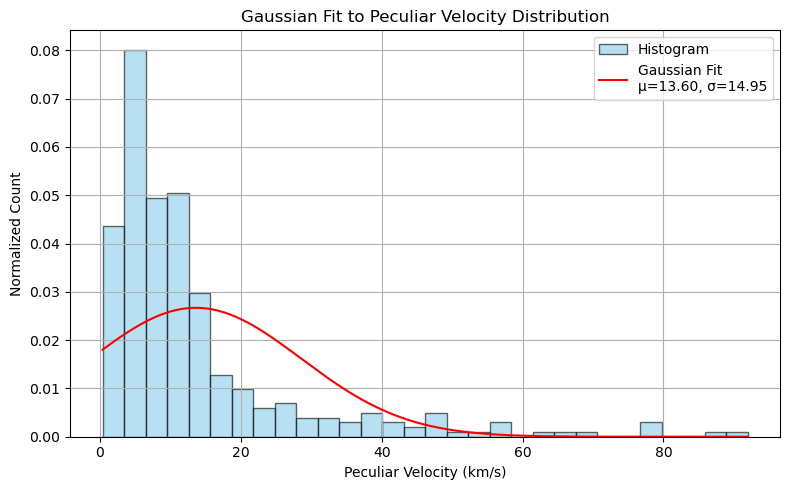

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Replace this with your actual data
gosc_pd = gosc_pd[gosc_pd['parallax']/gosc_pd['parallax_error'] >5.0]

gosc_pd = gosc_pd[gosc_pd['ruwe'] <1.4]
peculiar_velocity = gosc_pd['Peculiar Velocity'].dropna().values


print(len(peculiar_velocity))
# Fit a Gaussian: get mean and standard deviation
mu, std = norm.fit(peculiar_velocity)

# Plot histogram
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(peculiar_velocity, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='k', label='Histogram')

# Plot fitted Gaussian
x = np.linspace(min(bins), max(bins), 1000)
pdf = norm.pdf(x, mu, std)
plt.plot(x, pdf, 'r-', label=f'Gaussian Fit\nμ={mu:.2f}, σ={std:.2f}')

# Labels and legend
plt.xlabel('Peculiar Velocity (km/s)')
plt.ylabel('Normalized Count')
plt.title('Gaussian Fit to Peculiar Velocity Distribution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [30]:
sigma_cliped_vpec = sigma_clip(peculiar_velocity, sigma=3.0)

In [31]:
np.mean(sigma_cliped_vpec)
np.std(sigma_cliped_vpec)

np.float64(5.281965310590754)

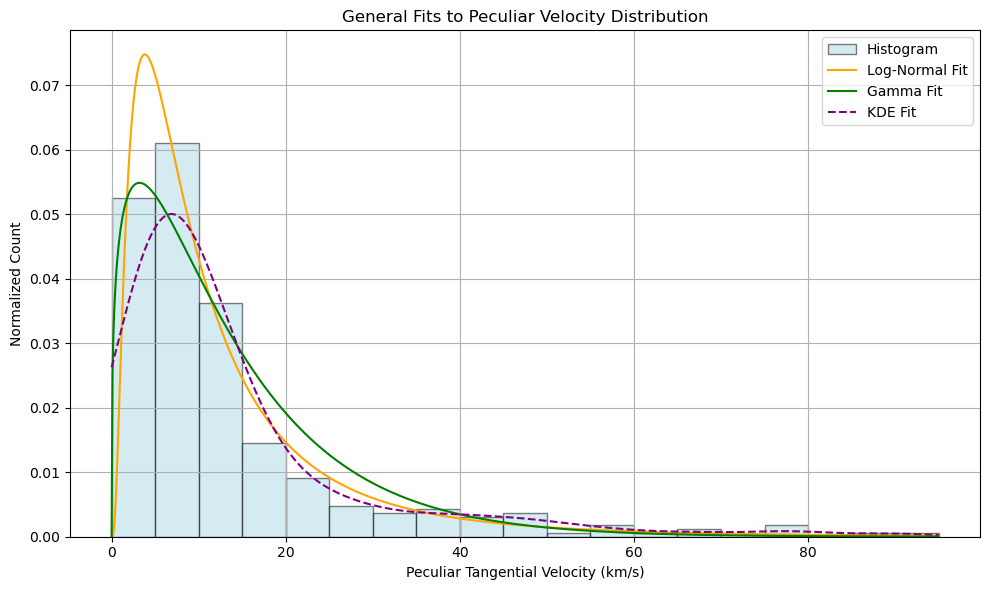

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, lognorm, gamma
from scipy.stats import gaussian_kde

# Clean data

peculiar_velocity = gosc_pd['Peculiar Velocity'].dropna().values

# Histogram
plt.figure(figsize=(10, 6))
bin_edges = np.arange(np.floor(peculiar_velocity.min()), np.ceil(peculiar_velocity.max()) + 5, 5)
counts, bins, _ = plt.hist(peculiar_velocity, bins=bin_edges, density=True,
                           alpha=0.5, color='lightblue', edgecolor='k', label='Histogram')

# X axis for plotting
x = np.linspace(0, max(bins), 1000)

# Log-Normal Fit
shape, loc, scale = lognorm.fit(peculiar_velocity, floc=0)
lognorm_pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)
plt.plot(x, lognorm_pdf, 'orange', label=f'Log-Normal Fit')

# Gamma Fit
gamma_shape, gamma_loc, gamma_scale = gamma.fit(peculiar_velocity, floc=0)
gamma_pdf = gamma.pdf(x, gamma_shape, loc=gamma_loc, scale=gamma_scale)
plt.plot(x, gamma_pdf, 'green', label=f'Gamma Fit')

# KDE Fit (Non-parametric)
kde = gaussian_kde(peculiar_velocity)
plt.plot(x, kde(x), 'purple', linestyle='--', label='KDE Fit')

# Labels and legend
plt.xlabel('Peculiar Tangential Velocity (km/s)')
plt.ylabel('Normalized Count')
plt.title('General Fits to Peculiar Velocity Distribution')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


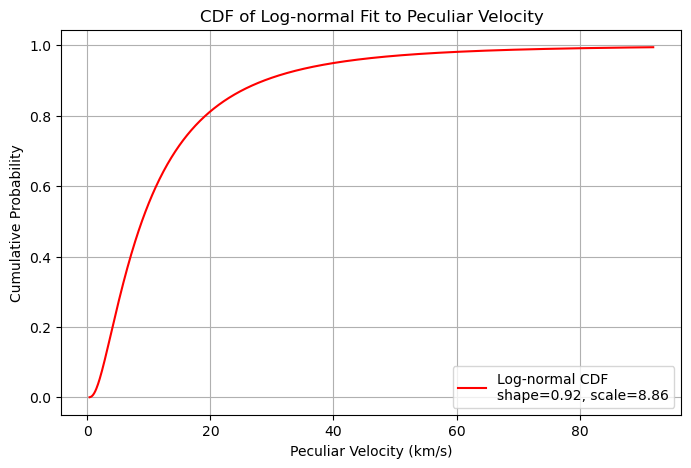

In [33]:
x = np.linspace(min(peculiar_velocity), max(peculiar_velocity), 1000)
cdf = lognorm.cdf(x, shape, loc=loc, scale=scale)

# Plot CDF
plt.figure(figsize=(8, 5))
plt.plot(x, cdf, 'r-', label=f'Log-normal CDF\nshape={shape:.2f}, scale={scale:.2f}')
plt.xlabel('Peculiar Velocity (km/s)')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Log-normal Fit to Peculiar Velocity')
plt.grid(True)
plt.legend()

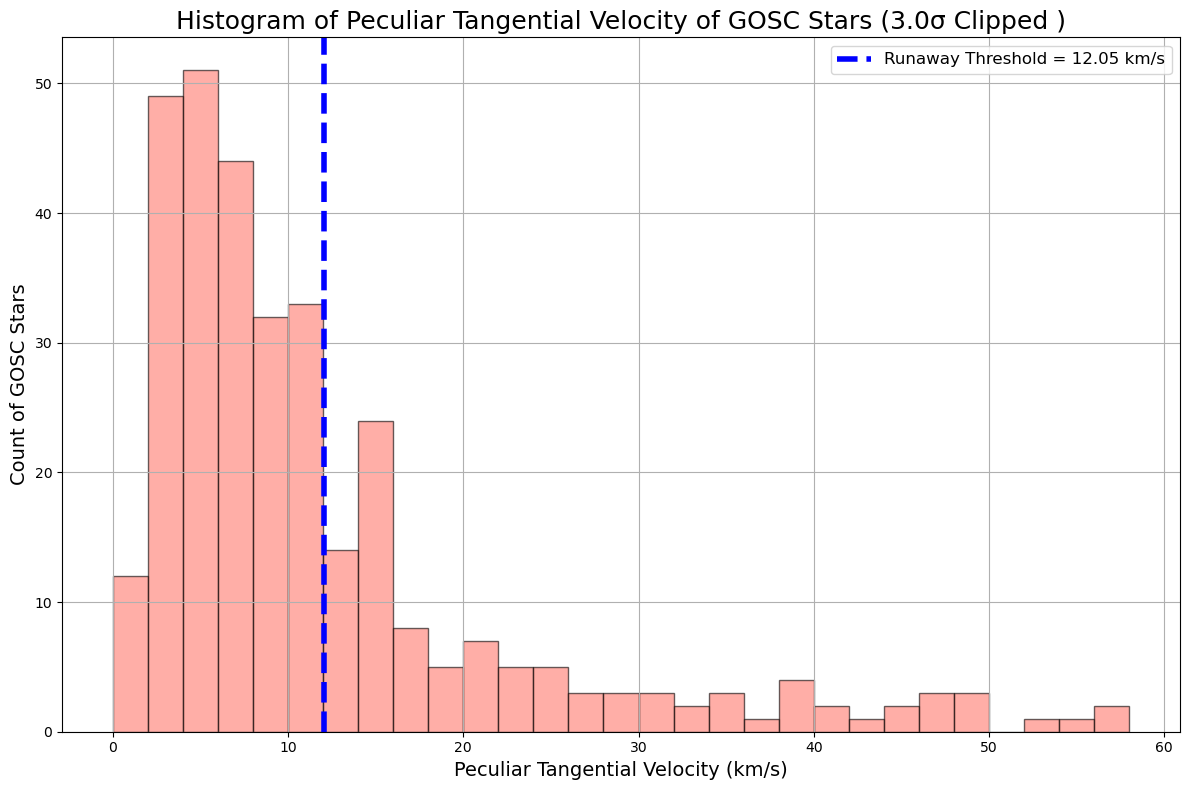

Initial Fit: μ = 13.60, σ = 14.95
After Sigma Clipping: μ = 12.05, σ = 11.25


In [34]:
# Filter on parallax SNR
gosc_pd = gosc_pd[gosc_pd['parallax'] / gosc_pd['parallax_error'] > 5.0]
peculiar_velocity = gosc_pd['Peculiar Velocity'].dropna().values

# Initial fit to estimate mean and std
mu_initial, std_initial = norm.fit(peculiar_velocity)

# Sigma clipping: remove points more than 3σ from the initial mean
sigma = 3.0
clipped = peculiar_velocity[np.abs(peculiar_velocity - mu_initial) < sigma * std_initial]

# Fit again to the clipped data
mu_clipped, std_clipped = norm.fit(clipped)

# Histogram with 5 km/s bin width
bin_width = 2
bins = np.arange(start=np.floor(clipped.min()), stop=np.ceil(clipped.max()) + bin_width, step=bin_width)
plt.figure(figsize=(12,8))
counts, bins, patches = plt.hist(clipped, bins=bins, density=False, alpha=0.6, color='xkcd:salmon', edgecolor='k',rwidth=1.0)
# Plot the mean as a vertical line
plt.axvline(mu_clipped, color='blue', linestyle='--', linewidth=4, label=f'Runaway Threshold = {mu_clipped:.2f} km/s')




# X axis for plotting
# x = np.linspace(0, max(bins), 1000)

# # Log-Normal Fit
# shape, loc, scale = lognorm.fit(peculiar_velocity, floc=0)
# lognorm_pdf = lognorm.pdf(x, shape, loc=loc, scale=scale)
# plt.plot(x, lognorm_pdf, 'orange', label=f'Log-Normal Fit')

# # Gamma Fit
# gamma_shape, gamma_loc, gamma_scale = gamma.fit(peculiar_velocity, floc=0)
# gamma_pdf = gamma.pdf(x, gamma_shape, loc=gamma_loc, scale=gamma_scale)
# plt.plot(x, gamma_pdf, 'green', label=f'Gamma Fit')

# # KDE Fit (Non-parametric)
# kde = gaussian_kde(peculiar_velocity)
# plt.plot(x, kde(x), 'purple', linestyle='--', label='KDE Fit')


# Labels and legend
plt.xlabel('Peculiar Tangential Velocity (km/s)', fontsize=14)
plt.ylabel('Count of GOSC Stars',fontsize=14)
plt.title(f"Histogram of Peculiar Tangential Velocity of GOSC Stars ({sigma}σ Clipped )",fontsize=18)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig(home_files + '/Figures/' +
                    f'Gosc_sigma_clipped.png',
                    dpi=300,
                   bbox_inches='tight')
plt.show()

# Print statistics
print(f"Initial Fit: μ = {mu_initial:.2f}, σ = {std_initial:.2f}")
print(f"After Sigma Clipping: μ = {mu_clipped:.2f}, σ = {std_clipped:.2f}")


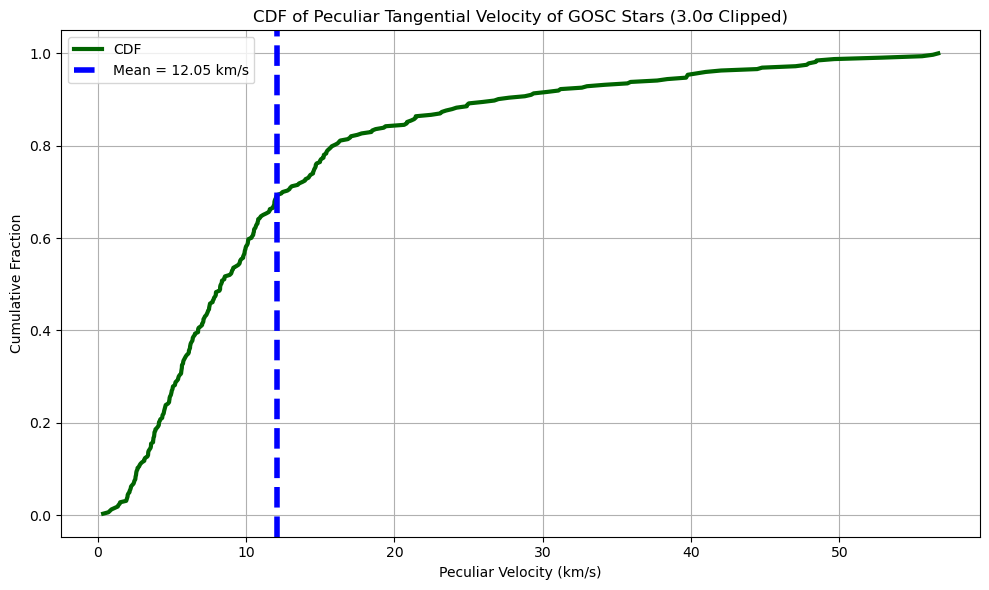

In [35]:
# Sort the clipped velocities
sorted_vel = np.sort(clipped)
cdf = np.arange(1, len(sorted_vel)+1) / len(sorted_vel)

# Plot CDF
plt.figure(figsize=(10, 6))
plt.plot(sorted_vel, cdf, color='darkgreen', label='CDF',linewidth=3.0)
plt.axvline(mu_clipped, color='blue', linestyle='--', label=f'Mean = {mu_clipped:.2f} km/s',linewidth=4.0)

# Labels
plt.xlabel('Peculiar Velocity (km/s)')
plt.ylabel('Cumulative Fraction')
plt.title(f"CDF of Peculiar Tangential Velocity of GOSC Stars ({sigma}σ Clipped)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(home_files + '/Figures/' +
                    f'Gosc_cdf.png',
                    dpi=300,
                   bbox_inches='tight')
plt.show()


331


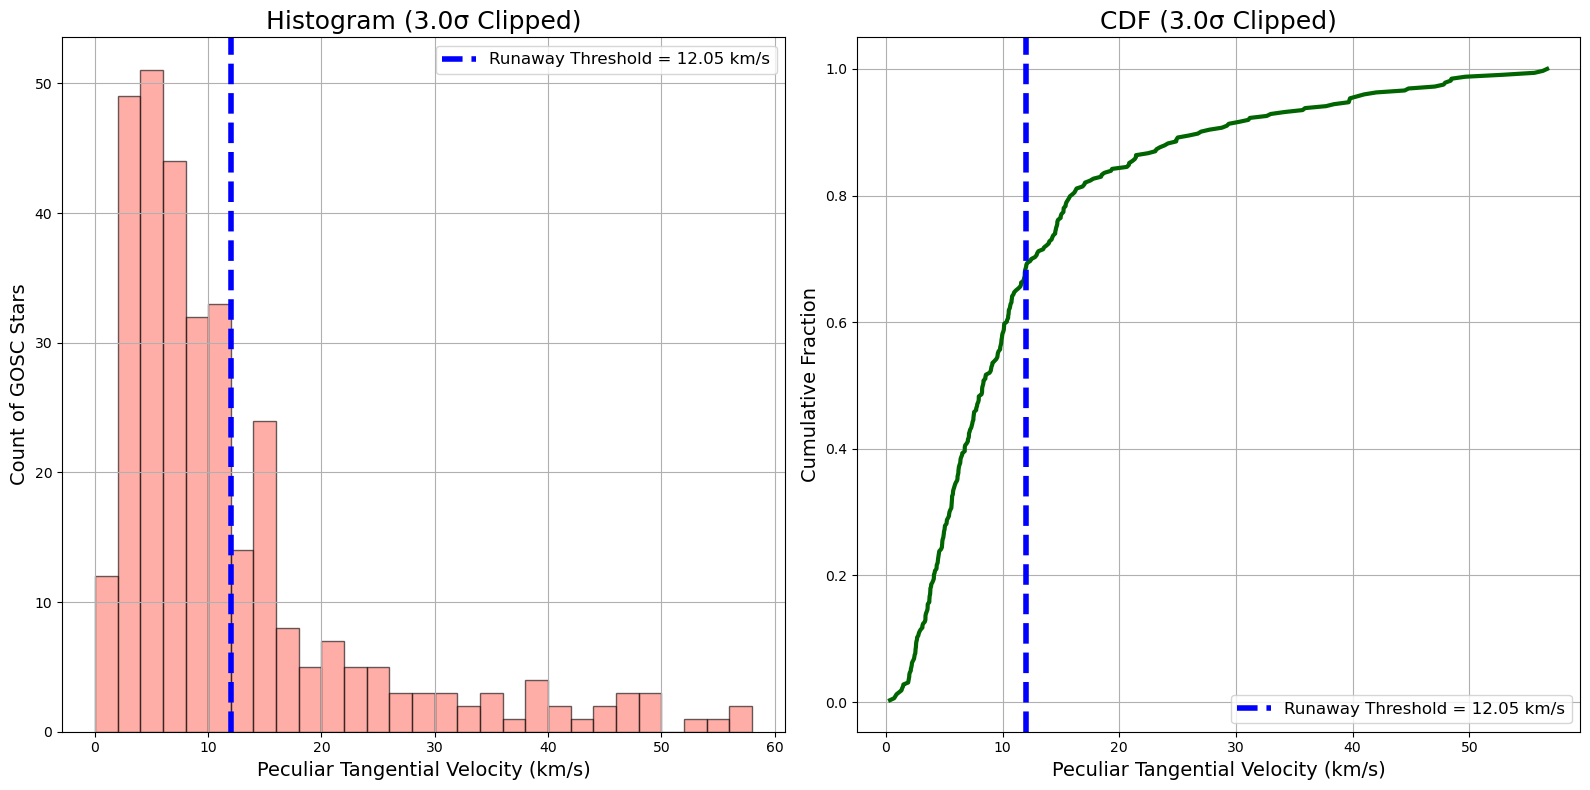

Initial Fit: μ = 13.60, σ = 14.95
After Sigma Clipping: μ = 12.05, σ = 11.25


In [41]:


# Filter on parallax SNR
gosc_pd = gosc_pd[gosc_pd['parallax'] / gosc_pd['parallax_error'] > 5.0]
peculiar_velocity = gosc_pd['Peculiar Velocity'].dropna().values
print(len(peculiar_velocity))

# Initial fit to estimate mean and std
mu_initial, std_initial = norm.fit(peculiar_velocity)

# Sigma clipping
sigma = 3.0
clipped = peculiar_velocity[np.abs(peculiar_velocity - mu_initial) < sigma * std_initial]

# Refit after clipping
mu_clipped, std_clipped = norm.fit(clipped)

# Histogram settings
bin_width = 2
bins = np.arange(start=np.floor(clipped.min()), stop=np.ceil(clipped.max()) + bin_width, step=bin_width)

# Set up side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

# --- Left: Histogram ---
counts, bins_hist, patches = ax1.hist(clipped, bins=bins, density=False, alpha=0.6,
                                      color='xkcd:salmon', edgecolor='k', rwidth=1.0)


ax1.axvline(mu_clipped, color='blue', linestyle='--', linewidth=4,
            label=f'Runaway Threshold = {mu_clipped:.2f} km/s')
ax1.set_xlabel('Peculiar Tangential Velocity (km/s)', fontsize=14)
ax1.set_ylabel('Count of GOSC Stars', fontsize=14)
ax1.set_title(f'Histogram ({sigma}σ Clipped)', fontsize=18)
ax1.legend(fontsize=12)
ax1.grid(True)

# --- Right: CDF ---
sorted_vel = np.sort(clipped)
cdf = np.arange(1, len(sorted_vel)+1) / len(sorted_vel)

ax2.plot(sorted_vel, cdf, color='darkgreen',linewidth=3.0)
ax2.axvline(mu_clipped, color='blue', linestyle='--', linewidth=4.0,
            label=f'Runaway Threshold = {mu_clipped:.2f} km/s')
ax2.set_xlabel('Peculiar Tangential Velocity (km/s)', fontsize=14)
ax2.set_ylabel('Cumulative Fraction', fontsize=14)
ax2.set_title(f'CDF ({sigma}σ Clipped)', fontsize=18)
ax2.legend(fontsize=12)
ax2.grid(True)

# Save and show
plt.tight_layout()
plt.savefig(home_files + '/Figures/Gosc_histogram_cdf_combined.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Print stats
print(f"Initial Fit: μ = {mu_initial:.2f}, σ = {std_initial:.2f}")
print(f"After Sigma Clipping: μ = {mu_clipped:.2f}, σ = {std_clipped:.2f}")


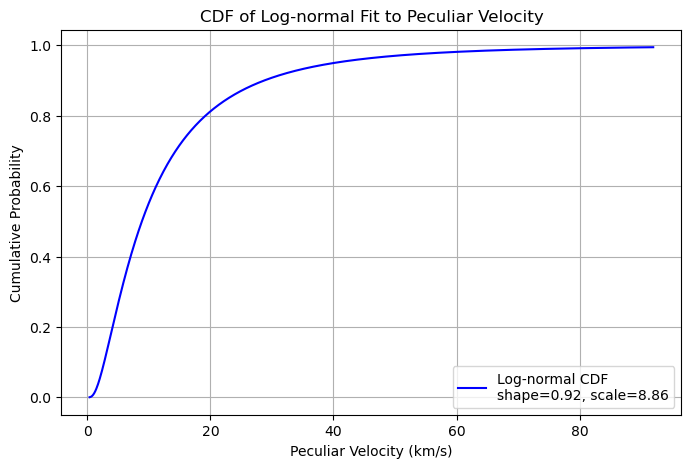

In [37]:
x = np.linspace(min(peculiar_velocity), max(peculiar_velocity), 1000)
cdf = lognorm.cdf(x, shape, loc=loc, scale=scale)

# Plot CDF
plt.figure(figsize=(8, 5))
plt.plot(x, cdf, 'b', label=f'Log-normal CDF\nshape={shape:.2f}, scale={scale:.2f}')
plt.xlabel('Peculiar Velocity (km/s)')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Log-normal Fit to Peculiar Velocity')
plt.grid(True)
plt.legend()

In [38]:
import numpy as np
import pandas as pd
from scipy.stats import norm, lognorm, gamma
import matplotlib.pyplot as plt

# Filter your DataFrame
gosc_pd = gosc_pd[gosc_pd['parallax'] / gosc_pd['parallax_error'] > 5.0]
data = gosc_pd['Peculiar Velocity'].dropna().values
n = len(data)

def compute_aic_bic(log_likelihood, num_params, n):
    aic = 2 * num_params - 2 * log_likelihood
    bic = num_params * np.log(n) - 2 * log_likelihood
    return aic, bic

# --- Gaussian Fit ---
mu_norm, std_norm = norm.fit(data)
ll_norm = np.sum(norm.logpdf(data, mu_norm, std_norm))
aic_norm, bic_norm = compute_aic_bic(ll_norm, 2, n)

# --- Log-Normal Fit ---
shape_logn, loc_logn, scale_logn = lognorm.fit(data, floc=0)
mu_logn = np.mean(lognorm.rvs(shape_logn, loc=loc_logn, scale=scale_logn, size=100000))
std_logn = np.std(lognorm.rvs(shape_logn, loc=loc_logn, scale=scale_logn, size=100000))
ll_logn = np.sum(lognorm.logpdf(data, shape_logn, loc=loc_logn, scale=scale_logn))
aic_logn, bic_logn = compute_aic_bic(ll_logn, 3, n)

# --- Gamma Fit ---
shape_gamma, loc_gamma, scale_gamma = gamma.fit(data, floc=0)
mu_gamma = np.mean(gamma.rvs(shape_gamma, loc=loc_gamma, scale=scale_gamma, size=100000))
std_gamma = np.std(gamma.rvs(shape_gamma, loc=loc_gamma, scale=scale_gamma, size=100000))
ll_gamma = np.sum(gamma.logpdf(data, shape_gamma, loc=loc_gamma, scale=scale_gamma))
aic_gamma, bic_gamma = compute_aic_bic(ll_gamma, 3, n)

# --- Report ---
print(f"{'Model':<12} {'Mean':>10} {'Std Dev':>10} {'AIC':>10} {'BIC':>10}")
print("-" * 56)
print(f"{'Gaussian':<12} {mu_norm:10.2f} {std_norm:10.2f} {aic_norm:10.2f} {bic_norm:10.2f}")
print(f"{'Log-Normal':<12} {mu_logn:10.2f} {std_logn:10.2f} {aic_logn:10.2f} {bic_logn:10.2f}")
print(f"{'Gamma':<12} {mu_gamma:10.2f} {std_gamma:10.2f} {aic_gamma:10.2f} {bic_gamma:10.2f}")


Model              Mean    Std Dev        AIC        BIC
--------------------------------------------------------
Gaussian          13.60      14.95    2733.81    2741.42
Log-Normal        13.45      15.28    2332.82    2344.23
Gamma             13.58      11.99    2382.42    2393.82


# Peculiar Radial Velocity

38


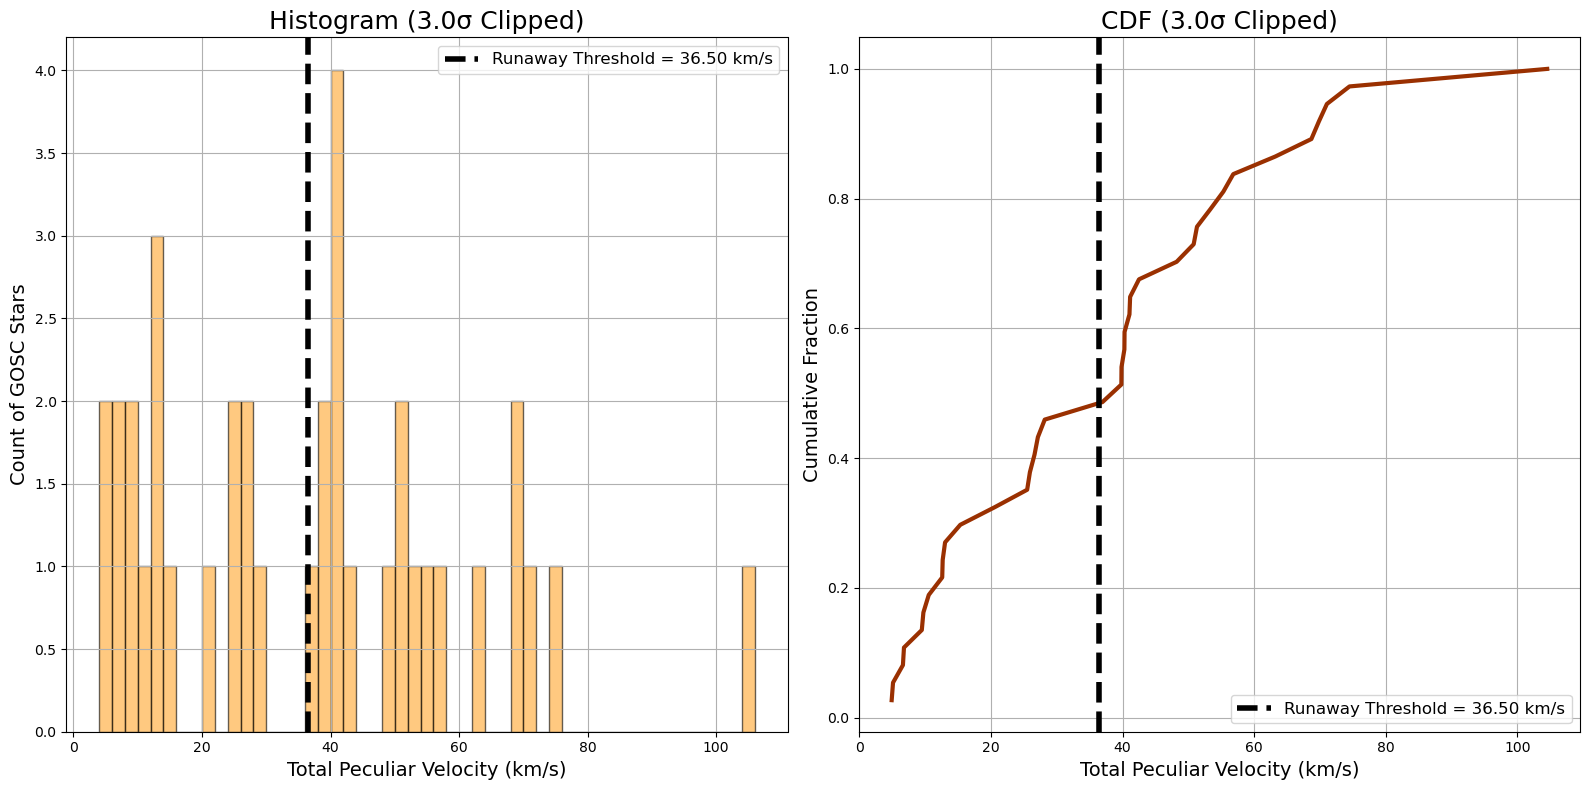

Initial Fit: μ = 38.77, σ = 27.08
After Sigma Clipping: μ = 36.50, σ = 23.60


In [39]:

# Filter on parallax SNR
gosc_pd = gosc_pd[gosc_pd['parallax'] / gosc_pd['parallax_error'] > 5.0]
peculiar_velocity = gosc_pd['Peculiar Velocity 3D'].dropna().values
print(len(peculiar_velocity))

# Initial fit to estimate mean and std
mu_initial, std_initial = norm.fit(peculiar_velocity)

# Sigma clipping
sigma = 3.0
clipped = peculiar_velocity[np.abs(peculiar_velocity - mu_initial) < sigma * std_initial]

# Refit after clipping
mu_clipped, std_clipped = norm.fit(clipped)

# Histogram settings
bin_width = 2
bins = np.arange(start=np.floor(clipped.min()), stop=np.ceil(clipped.max()) + bin_width, step=bin_width)

# Set up side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

# --- Left: Histogram ---
counts, bins_hist, patches = ax1.hist(clipped, bins=bins, density=False, alpha=0.6,
                                      color='xkcd:mango', edgecolor='k', rwidth=1.0)


ax1.axvline(mu_clipped, color='k', linestyle='--', linewidth=4,
            label=f'Runaway Threshold = {mu_clipped:.2f} km/s')
ax1.set_xlabel('Total Peculiar Velocity (km/s)', fontsize=14)
ax1.set_ylabel('Count of GOSC Stars', fontsize=14)
ax1.set_title(f'Histogram ({sigma}σ Clipped)', fontsize=18)
ax1.legend(fontsize=12)
ax1.grid(True)

# --- Right: CDF ---
sorted_vel = np.sort(clipped)
cdf = np.arange(1, len(sorted_vel)+1) / len(sorted_vel)

ax2.plot(sorted_vel, cdf, color='xkcd:auburn',linewidth=3.0)
ax2.axvline(mu_clipped, color='k', linestyle='--', linewidth=4.0,
            label=f'Runaway Threshold = {mu_clipped:.2f} km/s')
ax2.set_xlabel('Total Peculiar Velocity (km/s)', fontsize=14)
ax2.set_ylabel('Cumulative Fraction', fontsize=14)
ax2.set_title(f'CDF ({sigma}σ Clipped)', fontsize=18)
ax2.legend(fontsize=12)
ax2.grid(True)

# Save and show
plt.tight_layout()
plt.savefig(home_files + '/Figures/Total_Gosc_histogram_cdf_combined.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Print stats
print(f"Initial Fit: μ = {mu_initial:.2f}, σ = {std_initial:.2f}")
print(f"After Sigma Clipping: μ = {mu_clipped:.2f}, σ = {std_clipped:.2f}")

In [40]:

data = gosc_pd['Peculiar Velocity 3D'].dropna().values
n = len(data)

def compute_aic_bic(log_likelihood, num_params, n):
    aic = 2 * num_params - 2 * log_likelihood
    bic = num_params * np.log(n) - 2 * log_likelihood
    return aic, bic

# --- Gaussian Fit ---
mu_norm, std_norm = norm.fit(data)
ll_norm = np.sum(norm.logpdf(data, mu_norm, std_norm))
aic_norm, bic_norm = compute_aic_bic(ll_norm, 2, n)

# --- Log-Normal Fit ---
shape_logn, loc_logn, scale_logn = lognorm.fit(data, floc=0)
mu_logn = np.mean(lognorm.rvs(shape_logn, loc=loc_logn, scale=scale_logn, size=100000))
std_logn = np.std(lognorm.rvs(shape_logn, loc=loc_logn, scale=scale_logn, size=100000))
ll_logn = np.sum(lognorm.logpdf(data, shape_logn, loc=loc_logn, scale=scale_logn))
aic_logn, bic_logn = compute_aic_bic(ll_logn, 3, n)

# --- Gamma Fit ---
shape_gamma, loc_gamma, scale_gamma = gamma.fit(data, floc=0)
mu_gamma = np.mean(gamma.rvs(shape_gamma, loc=loc_gamma, scale=scale_gamma, size=100000))
std_gamma = np.std(gamma.rvs(shape_gamma, loc=loc_gamma, scale=scale_gamma, size=100000))
ll_gamma = np.sum(gamma.logpdf(data, shape_gamma, loc=loc_gamma, scale=scale_gamma))
aic_gamma, bic_gamma = compute_aic_bic(ll_gamma, 3, n)

# --- Report ---
print(f"{'Model':<12} {'Mean':>10} {'Std Dev':>10} {'AIC':>10} {'BIC':>10}")
print("-" * 56)
print(f"{'Gaussian':<12} {mu_norm:10.2f} {std_norm:10.2f} {aic_norm:10.2f} {bic_norm:10.2f}")
print(f"{'Log-Normal':<12} {mu_logn:10.2f} {std_logn:10.2f} {aic_logn:10.2f} {bic_logn:10.2f}")
print(f"{'Gamma':<12} {mu_gamma:10.2f} {std_gamma:10.2f} {aic_gamma:10.2f} {bic_gamma:10.2f}")


Model              Mean    Std Dev        AIC        BIC
--------------------------------------------------------
Gaussian          38.77      27.08     362.54     365.81
Log-Normal        41.23      41.98     356.29     361.20
Gamma             38.79      28.62     352.99     357.90
